# Revolut case study

### Import packages

In [64]:
import numpy as np
import pandas as pd
import ast # for converting data to dict

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.ticker import PercentFormatter

import seaborn as sns

In [2]:
# Import files
doc_report = pd.read_csv('doc_report.csv', )
facial_report = pd.read_csv('facial_similarity_report.csv')

### Exploratory data analysis

In [3]:
# View the data 
doc_report.head()

,number,user_id,result,visual_authenticity_result,image_integrity_result,face_detection_result,image_quality_result,created_at,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,attempt_id,police_record_result,compromised_document_result,properties,sub_result
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,consider,consider,clear,clear,clear,2017-06-20T23:12:57Z,clear,NaN,NaN,clear,clear,NaN,050a0596de424fab83c433eaa18b3f8d,clear,NaN,"{'gender': 'Male', 'nationality': 'IRL', 'docu...",caution
1,1,15a84e8951254011b47412fa4e8f65b8,clear,clear,clear,clear,clear,2017-06-20T23:16:04Z,clear,NaN,NaN,clear,NaN,NaN,f69c1e5f45a64e50a26740b9bfb978b7,clear,NaN,"{'gender': 'Female', 'document_type': 'driving...",clear
2,2,ffb82fda52b041e4b9af9cb4ef298c85,clear,clear,clear,clear,clear,2017-06-20T17:59:49Z,clear,NaN,NaN,clear,clear,NaN,f9f84f3055714d8e8f7419dc984d1769,clear,NaN,"{'gender': 'Male', 'nationality': 'ITA', 'docu...",clear
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,clear,clear,clear,clear,clear,2017-06-20T17:59:38Z,clear,NaN,NaN,clear,clear,NaN,10a54a1ecf794404be959e030f11fef6,clear,NaN,"{'gender': 'Male', 'issuing_date': '2007-08', ...",clear
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,clear,clear,clear,clear,clear,2017-06-20T18:08:09Z,clear,NaN,NaN,clear,clear,NaN,1f320d1d07de493292b7e0d5ebfb1cb9,clear,NaN,"{'gender': 'Male', 'nationality': 'POL', 'docu...",clear


### Initial findings: 
- created_date column containing timestamp 
- attempt_id in the middle of the table 
- properties column containing dict like data

In [4]:
# Gathering info on the dataset 
doc_report.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176404 entries, 0 to 176403
Data columns (total 19 columns):
 #   Column                              Non-Null Count   Dtype 
---  ------                              --------------   ----- 
 0   number                              176404 non-null  int64 
 1   user_id                             176404 non-null  object
 2   result                              176404 non-null  object
 3   visual_authenticity_result          150290 non-null  object
 4   image_integrity_result              176403 non-null  object
 5   face_detection_result               150261 non-null  object
 6   image_quality_result                176403 non-null  object
 7   created_at                          176404 non-null  object
 8   supported_document_result           175900 non-null  object
 9   conclusive_document_quality_result  95217 non-null   object
 10  colour_picture_result               95222 non-null   object
 11  data_validation_result              142

In [5]:
# Avoid issues with large numeric IDs 
doc_report['user_id'] = doc_report['user_id'].astype(str)
doc_report['attempt_id'] = doc_report['attempt_id'].astype(str)

In [6]:
# Convert created_at to date 
doc_report['created_at'] = pd.to_datetime(doc_report['created_at'])

In [7]:
# Create a creation date column
doc_report['created_date'] = doc_report['created_at'].dt.date

In [8]:
# Fill NaN with 

### Place ID columns at the beginning

In [9]:
# Move attempt ID to the front of the DF
cols = ['number','user_id','attempt_id'] + [col for col in doc_report.columns if col not in ['number','user_id','attempt_id']]
doc_report = doc_report[cols]

In [10]:
doc_report

,number,user_id,attempt_id,result,visual_authenticity_result,image_integrity_result,face_detection_result,image_quality_result,created_at,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,police_record_result,compromised_document_result,properties,sub_result,created_date
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,consider,consider,clear,clear,clear,2017-06-20 23:12:57+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Male', 'nationality': 'IRL', 'docu...",caution,2017-06-20
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,clear,clear,clear,2017-06-20 23:16:04+00:00,clear,NaN,NaN,clear,NaN,NaN,clear,NaN,"{'gender': 'Female', 'document_type': 'driving...",clear,2017-06-20
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,clear,clear,clear,2017-06-20 17:59:49+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Male', 'nationality': 'ITA', 'docu...",clear,2017-06-20
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,clear,clear,clear,2017-06-20 17:59:38+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Male', 'issuing_date': '2007-08', ...",clear,2017-06-20
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,clear,clear,clear,2017-06-20 18:08:09+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Male', 'nationality': 'POL', 'docu...",clear,2017-06-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,clear,clear,clear,2017-06-20 22:25:53+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Female', 'nationality': 'CHN', 'do...",clear,2017-06-20
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,clear,clear,clear,2017-06-20 22:27:40+00:00,clear,NaN,NaN,clear,NaN,NaN,clear,NaN,"{'gender': 'Female', 'document_type': 'driving...",clear,2017-06-20
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,clear,clear,clear,2017-06-20 22:25:59+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Female', 'nationality': 'GBR', 'do...",clear,2017-06-20
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,clear,clear,clear,2017-06-20 22:35:40+00:00,clear,NaN,NaN,clear,clear,NaN,clear,NaN,"{'gender': 'Male', 'nationality': 'PRT', 'docu...",clear,2017-06-20


In [11]:
#doc_report = doc_report.drop('properties_v2', axis=1)

### Flatten properties

In [12]:
# Check data type of properties column 
doc_report['properties'].apply(type)

0         <class 'str'>
1         <class 'str'>
2         <class 'str'>
3         <class 'str'>
4         <class 'str'>
              ...      
176399    <class 'str'>
176400    <class 'str'>
176401    <class 'str'>
176402    <class 'str'>
176403    <class 'str'>
Name: properties, Length: 176404, dtype: object

In [13]:
# Handling strings that look like dicts
doc_report['properties'] = doc_report['properties'].apply(ast.literal_eval)

In [14]:
# Set the dtype explicitly for any empty entries before applying .apply(pd.Series) to avoid warning message
doc_report['properties'] = doc_report['properties'].apply(lambda x: x if isinstance(x, dict) else {})

# Flatten the dict column
doc_expanded = doc_report['properties'].apply(pd.Series)

In [15]:
# View flattened data
doc_expanded

,gender,nationality,document_type,date_of_expiry,issuing_country,issuing_date,issuing_state,document_version
0,Male,IRL,passport,2019-08-12,IRL,NaN,NaN,NaN
1,Female,NaN,driving_licence,2023-02-28,GBR,NaN,NaN,NaN
2,Male,ITA,passport,2018-06-09,ITA,NaN,NaN,NaN
3,Male,NaN,national_identity_card,NaN,FRA,2007-08,NaN,NaN
4,Male,POL,national_identity_card,2019-05-29,POL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
176399,Female,CHN,passport,2027-04-23,CHN,NaN,NaN,NaN
176400,Female,NaN,driving_licence,2026-04-20,GBR,NaN,NaN,NaN
176401,Female,GBR,passport,2023-07-11,GBR,NaN,NaN,NaN
176402,Male,PRT,passport,2019-10-16,PRT,NaN,NaN,NaN


In [16]:
# Add user and attempt IDs to the dataset 
doc_expanded[['user_id','attempt_id']] = doc_report[['user_id','attempt_id']]

# Move ID columns to the front
cols = ['user_id','attempt_id'] + [col for col in doc_expanded.columns if col not in ['user_id','attempt_id']]
doc_expanded = doc_expanded[cols]

In [17]:
# See the dataset
doc_expanded

,user_id,attempt_id,gender,nationality,document_type,date_of_expiry,issuing_country,issuing_date,issuing_state,document_version
0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,Male,IRL,passport,2019-08-12,IRL,NaN,NaN,NaN
1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,Female,NaN,driving_licence,2023-02-28,GBR,NaN,NaN,NaN
2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,Male,ITA,passport,2018-06-09,ITA,NaN,NaN,NaN
3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,Male,NaN,national_identity_card,NaN,FRA,2007-08,NaN,NaN
4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,Male,POL,national_identity_card,2019-05-29,POL,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
176399,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,Female,CHN,passport,2027-04-23,CHN,NaN,NaN,NaN
176400,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,Female,NaN,driving_licence,2026-04-20,GBR,NaN,NaN,NaN
176401,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,Female,GBR,passport,2023-07-11,GBR,NaN,NaN,NaN
176402,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,Male,PRT,passport,2019-10-16,PRT,NaN,NaN,NaN


In [18]:
# Nationality vs. issuing country


# Missing values
print(doc_expanded.isnull().sum())

user_id                  0
attempt_id               0
gender               56466
nationality          97932
document_type        26106
date_of_expiry       47289
issuing_country      26103
issuing_date        124611
issuing_state       175610
document_version    176342
dtype: int64


In [19]:
# Missing values
print(doc_report.isnull().sum())

number                                     0
user_id                                    0
attempt_id                                 0
result                                     0
visual_authenticity_result             26114
image_integrity_result                     1
face_detection_result                  26143
image_quality_result                       1
created_at                                 0
supported_document_result                504
conclusive_document_quality_result     81187
colour_picture_result                  81182
data_validation_result                 33430
data_consistency_result                84175
data_comparison_result                173856
police_record_result                   31847
compromised_document_result           130898
properties                                 0
sub_result                                 0
created_date                               0
dtype: int64


In [20]:
# Categorical column check: result
doc_report.value_counts('result')

result
clear       132402
consider     44002
Name: count, dtype: int64

### Facial similarity report

In [21]:
# View first few rows of the dataset
facial_report.head()

,number,user_id,result,face_comparison_result,created_at,facial_image_integrity_result,visual_authenticity_result,properties,attempt_id
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,clear,clear,2017-06-20T23:12:58Z,clear,consider,{},050a0596de424fab83c433eaa18b3f8d
1,1,15a84e8951254011b47412fa4e8f65b8,clear,clear,2017-06-20T23:16:04Z,clear,clear,{},f69c1e5f45a64e50a26740b9bfb978b7
2,2,ffb82fda52b041e4b9af9cb4ef298c85,clear,clear,2017-06-20T17:59:49Z,clear,clear,{},f9f84f3055714d8e8f7419dc984d1769
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,clear,clear,2017-06-20T17:59:39Z,clear,clear,{},10a54a1ecf794404be959e030f11fef6
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,clear,clear,2017-06-20T18:08:09Z,clear,clear,{},1f320d1d07de493292b7e0d5ebfb1cb9


In [22]:
# Reorder columns to have IDs in the first two columns

# Get columns names 
cols = list(facial_report.columns)

# Move last column to second position
last_col = cols[-1]
new_order = [cols[0],cols[1],last_col] + cols[2:-1]

# Reorder the DF
facial_report = facial_report[new_order]

In [23]:
# Get a summary of the DataFrame (structure, data types, missing values)
facial_report.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176404 entries, 0 to 176403
Data columns (total 9 columns):
 #   Column                         Non-Null Count   Dtype 
---  ------                         --------------   ----- 
 0   number                         176404 non-null  int64 
 1   user_id                        176404 non-null  object
 2   attempt_id                     176404 non-null  object
 3   result                         176403 non-null  object
 4   face_comparison_result         166007 non-null  object
 5   created_at                     176404 non-null  object
 6   facial_image_integrity_result  175941 non-null  object
 7   visual_authenticity_result     150290 non-null  object
 8   properties                     176404 non-null  object
dtypes: int64(1), object(8)
memory usage: 12.1+ MB


In [24]:
# Avoid issues with large numeric IDs 
facial_report['user_id'] = facial_report['user_id'].astype(str)
facial_report['attempt_id'] = facial_report['attempt_id'].astype(str)

In [25]:
# Convert created_at to date format
facial_report['created_at'] = pd.to_datetime(facial_report['created_at'])

# Create 

In [26]:
# Check properties column: We suspect that they only contain {} and are not necessary
facial_report['properties_length'] = facial_report['properties'].str.len()

print(facial_report.groupby('properties_length').size())

# Express results as percentages
percentage_by_length = facial_report['properties_length'].value_counts(normalize=True) * 100
print(percentage_by_length)

properties_length
2     172921
14       324
15      3159
dtype: int64
properties_length
2     98.025555
15     1.790776
14     0.183669
Name: proportion, dtype: float64


In [27]:
# Check information in propertie s
facial_report['properties'].value_counts(normalize=True) * 100

properties
{}                 98.025555
{'score': 0.69}     0.095803
{'score': 0.64}     0.092402
{'score': 0.63}     0.090134
{'score': 0.66}     0.090134
                     ...    
{'score': 0.1}      0.000567
{'score': 0.14}     0.000567
{'score': 0.88}     0.000567
{'score': 0.19}     0.000567
{'score': 0.21}     0.000567
Name: proportion, Length: 80, dtype: float64

In [28]:
# 
facial_report.loc[facial_report['properties'] != '{}','properties']

710       {'score': 0.69}
712       {'score': 0.67}
732       {'score': 0.64}
763       {'score': 0.51}
765       {'score': 0.56}
               ...       
172439    {'score': 0.66}
173187    {'score': 0.82}
173544    {'score': 0.67}
173561     {'score': 0.7}
174884    {'score': 0.77}
Name: properties, Length: 3483, dtype: object

In [29]:
facial_report['properties'].apply(type)

0         <class 'str'>
1         <class 'str'>
2         <class 'str'>
3         <class 'str'>
4         <class 'str'>
              ...      
176399    <class 'str'>
176400    <class 'str'>
176401    <class 'str'>
176402    <class 'str'>
176403    <class 'str'>
Name: properties, Length: 176404, dtype: object

In [30]:
# Handling strings that look like dicts
facial_report['properties_v2'] = facial_report['properties'].apply(ast.literal_eval)

In [31]:
# Flatten the dict column
facial_report_expanded = facial_report['properties_v2'].apply(pd.Series, dtype='str')

In [32]:
# Add user and attempt IDs to the dataset 
facial_report_expanded[['user_id','attempt_id']] = facial_report[['user_id','attempt_id']]

# Move ID columns to the front
cols = ['user_id','attempt_id'] + [col for col in facial_report_expanded.columns if col not in ['user_id','attempt_id']]
facial_report_expanded = facial_report_expanded[cols]

In [33]:
facial_report_expanded

,user_id,attempt_id,score
0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,NaN
1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,NaN
2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,NaN
3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,NaN
4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,NaN
...,...,...,...
176399,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,NaN
176400,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,NaN
176401,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,NaN
176402,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,NaN


### Data cleaning

### Data analysis

In [34]:
doc_report.columns

Index(['number', 'user_id', 'attempt_id', 'result',
       'visual_authenticity_result', 'image_integrity_result',
       'face_detection_result', 'image_quality_result', 'created_at',
       'supported_document_result', 'conclusive_document_quality_result',
       'colour_picture_result', 'data_validation_result',
       'data_consistency_result', 'data_comparison_result',
       'police_record_result', 'compromised_document_result', 'properties',
       'sub_result', 'created_date'],
      dtype='object')

In [35]:
doc_report_subset = doc_report.drop(['number','properties'],axis=1)

In [36]:
doc_report_subset = doc_report_subset.rename(columns ={
    'result':'doc_result',
    'created_at':'doc_created_at',
    'created_date':'doc_created_date',
    'sub_result':'doc_sub_result'
})

In [37]:
facial_report.columns

Index(['number', 'user_id', 'attempt_id', 'result', 'face_comparison_result',
       'created_at', 'facial_image_integrity_result',
       'visual_authenticity_result', 'properties', 'properties_length',
       'properties_v2'],
      dtype='object')

In [38]:
facial_report_subset = facial_report.drop(['properties','properties_length','properties_v2'],axis=1)

In [39]:
facial_report_subset = facial_report_subset.rename(columns = {
    'result':'facial_result',
    'created_at':'facial_created_at',
    'visual_authenticity_result':'facial_visual_authenticity_result'
})

In [40]:
facial_report_subset.columns

Index(['number', 'user_id', 'attempt_id', 'facial_result',
       'face_comparison_result', 'facial_created_at',
       'facial_image_integrity_result', 'facial_visual_authenticity_result'],
      dtype='object')

In [41]:
combined_check_results = facial_report_subset.merge(doc_report_subset, on=['user_id','attempt_id'],how='left')

In [42]:
combined_check_results

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,facial_visual_authenticity_result,doc_result,visual_authenticity_result,...,supported_document_result,conclusive_document_quality_result,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,police_record_result,compromised_document_result,doc_sub_result,doc_created_date
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,clear,clear,2017-06-20 23:12:58+00:00,clear,consider,consider,consider,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,caution,2017-06-20
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,2017-06-20 23:16:04+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,NaN,NaN,clear,NaN,clear,2017-06-20
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,2017-06-20 17:59:49+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,2017-06-20 17:59:39+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,2017-06-20 18:08:09+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,2017-06-20 22:25:53+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,2017-06-20 22:27:40+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,NaN,NaN,clear,NaN,clear,2017-06-20
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,2017-06-20 22:35:41+00:00,clear,clear,clear,clear,...,clear,NaN,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20


In [43]:
# Compare the two columns with visual_authentity_results
combined_check_results['facial_visual_authenticity_result'].equals(combined_check_results['visual_authenticity_result'])

True

In [46]:
# Drop one visual authenticity column to avoid duplication
combined_check_results = combined_check_results.drop('facial_visual_authenticity_result',axis=1)

KeyError: "['facial_visual_authenticity_result'] not found in axis"

### Analysis

In [55]:
# Display doc result over time 
doc_results = combined_check_results.groupby(['doc_created_date','doc_result']).size().unstack(fill_value=0) # Without .unstack(), you'd need extra logic to turn that multi-index Series into a usable table. With .unstack(), it's done in one line.

In [73]:
doc_results['doc_checks'] = doc_results['clear'] + doc_results['consider']

In [59]:
doc_results['clear_pct'] = doc_results['clear'] / (doc_results['clear'] + doc_results['consider']) 

In [74]:
doc_results

doc_result,clear,consider,clear_pct,doc_checks
doc_created_date,,,,
2017-05-23,91,9,0.910000,100
2017-05-24,178,16,0.917526,194
2017-05-25,150,15,0.909091,165
2017-05-26,194,19,0.910798,213
2017-05-27,159,15,0.913793,174
...,...,...,...,...
2017-10-27,1188,815,0.593110,2003
2017-10-28,1064,425,0.714574,1489
2017-10-29,1042,351,0.748026,1393


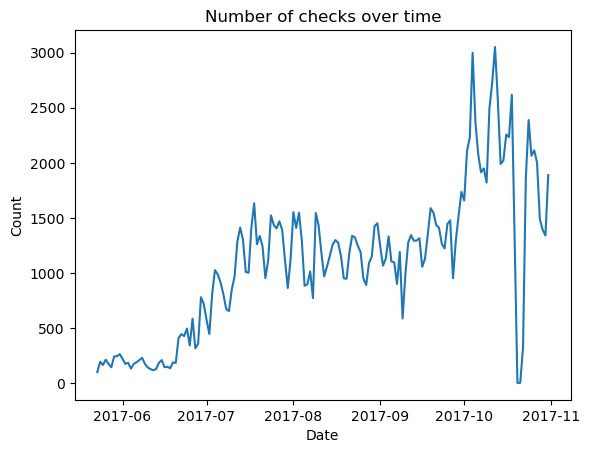

In [77]:
doc_results['doc_checks'].plot(kind='line')
plt.title('Number of checks over time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.show()

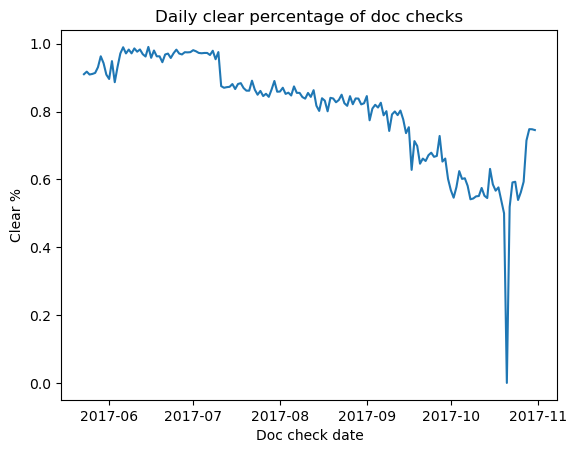

In [70]:
# Make the chart interactive

# Check clear contribution over time
doc_results['clear_pct'].plot(kind='line')
plt.title('Daily clear percentage of doc checks')
plt.xlabel('Doc check date')
plt.ylabel('Clear %')

#plt.gca().yaxis.set_major_formatter(PercentFormatter())

plt.show()

In [86]:
# Entries where both facial and document checks are clear 
combined_check_results['kyc_pass'] = combined_check_results.apply(lambda row: 1 if row['facial_result']=='clear' and row['doc_result']=='clear' else 0,axis=1)

In [95]:
# Calcualte if the user passed at least once
user_pass_rate = combined_check_results.groupby('user_id')['kyc_pass'].max()

In [96]:
user_pass_rate

user_id
000017082a4548d4aa480781069cf24c    1
000052fe85524411a593a999c2a24462    1
0000ae3e6cad4aa6b22a70c141cfebea    0
0001c1eacfdd4f1580b024de206c61e6    1
000215b70cd5498fa7384d7ccdc166c8    1
                                   ..
fffdf0314d2a42c8922e5b459804857b    1
fffe24c9067c41c5b217e25f457f4c45    1
fffe793811f24cdab0d6dca6c615d89c    1
ffff69137fd8419a8b2f521368cccce6    1
ffffb23498da427595799b6ecda5f70b    1
Name: kyc_pass, Length: 142724, dtype: int64

In [97]:
overall_pass_rate = user_pass_rate.mean()

In [90]:
overall_pass_rate

0.8509220593593229

In [116]:
# Combine data and user level data
user_pass_rate = combined_check_results.groupby(['user_id','doc_created_date'])['kyc_pass'].max().reset_index()

In [117]:
user_pass_rate

,user_id,doc_created_date,kyc_pass
0,000017082a4548d4aa480781069cf24c,2017-08-17,1
1,000052fe85524411a593a999c2a24462,2017-07-26,1
2,0000ae3e6cad4aa6b22a70c141cfebea,2017-10-04,0
3,0001c1eacfdd4f1580b024de206c61e6,2017-10-24,1
4,000215b70cd5498fa7384d7ccdc166c8,2017-07-29,1
...,...,...,...
148425,fffdf0314d2a42c8922e5b459804857b,2017-10-18,1
148426,fffe24c9067c41c5b217e25f457f4c45,2017-07-31,1
148427,fffe793811f24cdab0d6dca6c615d89c,2017-10-16,1
148428,ffff69137fd8419a8b2f521368cccce6,2017-10-28,1


In [105]:
date_pass_rate = user_pass_rate.groupby('doc_created_date')['kyc_pass'].mean().reset_index()

In [108]:
daily_tries = user_pass_rate.groupby('doc_created_date')['user_id'].nunique().reset_index()

In [110]:
daily_tries.rename(columns={'user_id':'unique_tries'},inplace=True)
daily_tries

,doc_created_date,unique_tries
0,2017-05-23,91
1,2017-05-24,178
2,2017-05-25,157
3,2017-05-26,193
4,2017-05-27,158
...,...,...
156,2017-10-27,1556
157,2017-10-28,1228
158,2017-10-29,1179
159,2017-10-30,1143


In [ ]:
# Idea: Post two charts next to each other: number of unique users per day and kyc pass rate 

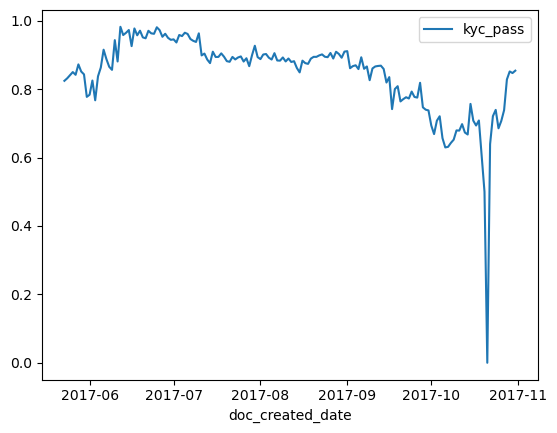

In [111]:
date_pass_rate.plot(x='doc_created_date', y='kyc_pass',kind='line')
plt.show()

In [118]:
combined_check_results

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,colour_picture_result,data_validation_result,data_consistency_result,data_comparison_result,police_record_result,compromised_document_result,doc_sub_result,doc_created_date,pass_rate,kyc_pass
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,clear,clear,2017-06-20 23:12:58+00:00,clear,consider,consider,clear,...,NaN,clear,clear,NaN,clear,NaN,caution,2017-06-20,Fail,0
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,2017-06-20 23:16:04+00:00,clear,clear,clear,clear,...,NaN,clear,NaN,NaN,clear,NaN,clear,2017-06-20,Pass,1
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,2017-06-20 17:59:49+00:00,clear,clear,clear,clear,...,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,2017-06-20 17:59:39+00:00,clear,clear,clear,clear,...,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,2017-06-20 18:08:09+00:00,clear,clear,clear,clear,...,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,2017-06-20 22:25:53+00:00,clear,clear,clear,clear,...,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,2017-06-20 22:27:40+00:00,clear,clear,clear,clear,...,NaN,clear,NaN,NaN,clear,NaN,clear,2017-06-20,Pass,1
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,2017-06-20 22:35:41+00:00,clear,clear,clear,clear,...,NaN,clear,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1


In [121]:
# see if fail is driven by facial or doc check results
combined_check_results['doc_fail'] = combined_check_results['doc_result'].apply(lambda x: 1 if x != 'clear' else 0)

In [122]:
combined_check_results['facial_fail'] = combined_check_results['facial_result'].map(lambda x: 1 if x !='clear' else 0)

In [123]:
combined_check_results

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,data_consistency_result,data_comparison_result,police_record_result,compromised_document_result,doc_sub_result,doc_created_date,pass_rate,kyc_pass,doc_fail,facial_fail
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,clear,clear,2017-06-20 23:12:58+00:00,clear,consider,consider,clear,...,clear,NaN,clear,NaN,caution,2017-06-20,Fail,0,1,0
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,2017-06-20 23:16:04+00:00,clear,clear,clear,clear,...,NaN,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,2017-06-20 17:59:49+00:00,clear,clear,clear,clear,...,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,2017-06-20 17:59:39+00:00,clear,clear,clear,clear,...,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,2017-06-20 18:08:09+00:00,clear,clear,clear,clear,...,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,2017-06-20 22:25:53+00:00,clear,clear,clear,clear,...,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,2017-06-20 22:27:40+00:00,clear,clear,clear,clear,...,NaN,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,2017-06-20 22:35:41+00:00,clear,clear,clear,clear,...,clear,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0


In [124]:
# Users with multiple tries
combined_check_results['user_id_count'] = combined_check_results.groupby('user_id')['user_id'].transform('count')

In [125]:
combined_check_results

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,data_comparison_result,police_record_result,compromised_document_result,doc_sub_result,doc_created_date,pass_rate,kyc_pass,doc_fail,facial_fail,user_id_count
0,0,ab23fae164e34af0a1ad1423ce9fd9f0,050a0596de424fab83c433eaa18b3f8d,clear,clear,2017-06-20 23:12:58+00:00,clear,consider,consider,clear,...,NaN,clear,NaN,caution,2017-06-20,Fail,0,1,0,1
1,1,15a84e8951254011b47412fa4e8f65b8,f69c1e5f45a64e50a26740b9bfb978b7,clear,clear,2017-06-20 23:16:04+00:00,clear,clear,clear,clear,...,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0,1
2,2,ffb82fda52b041e4b9af9cb4ef298c85,f9f84f3055714d8e8f7419dc984d1769,clear,clear,2017-06-20 17:59:49+00:00,clear,clear,clear,clear,...,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0,1
3,3,bd4a8b3e3601427e88aa1d9eab9f4290,10a54a1ecf794404be959e030f11fef6,clear,clear,2017-06-20 17:59:39+00:00,clear,clear,clear,clear,...,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0,1
4,4,f52ad1c7e69543a9940c3e7f8ed28a39,1f320d1d07de493292b7e0d5ebfb1cb9,clear,clear,2017-06-20 18:08:09+00:00,clear,clear,clear,clear,...,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176399,181987,c7f99ee763bf45d289019c6ac2cbd919,72a2cccc9e9942deb5274a16536bf2d0,clear,clear,2017-06-20 22:25:53+00:00,clear,clear,clear,clear,...,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0,1
176400,181988,8b47d72c363e4591861f523dd7487f20,8c83017191204a3887c2d47ca2d998ce,clear,clear,2017-06-20 22:27:40+00:00,clear,clear,clear,clear,...,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0,1
176401,181989,3d16e02c245a4f1a8a76662ad933d5c4,bfea35bcb6a940118ca5816cd8ffcae7,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0,2
176402,181990,65c49a09d299486091b6586487679b87,9190cf28b35b425083bdb41e121822fe,clear,clear,2017-06-20 22:35:41+00:00,clear,clear,clear,clear,...,NaN,clear,NaN,clear,2017-06-20,Pass,1,0,0,1


In [126]:
# Multiple tries and clear both 
multiple_tries = combined_check_results[combined_check_results['user_id_count']>1]

In [214]:
# Add order to show sequence of tests at user level
multiple_tries.loc[:,'order'] = multiple_tries.sort_values(by=['user_id','number']).groupby('user_id').cumcount()+1

In [215]:
multiple_tries

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,doc_sub_result,doc_created_date,pass_rate,kyc_pass,doc_fail,facial_fail,user_id_count,order,previous_kyc,neccessary_check
17,17,b20147d91fdf4ac289ddd80c4be9716a,2db4bd5ed28948af858881e5e261bc2d,clear,clear,2017-06-20 19:00:27+00:00,clear,clear,clear,clear,...,clear,2017-06-20,Pass,1,0,0,2,1,NaN,1
18,18,b20147d91fdf4ac289ddd80c4be9716a,aa906e5f7be04ebca1d79091f5294f58,clear,clear,2017-06-20 19:00:27+00:00,clear,clear,clear,clear,...,clear,2017-06-20,Pass,1,0,0,2,2,1.0,0
24,24,7e66b2c14ea74d28af5547be220455dd,e3549a16f4054976a7a994f1b268d195,clear,clear,2017-06-20 19:39:10+00:00,clear,clear,clear,clear,...,clear,2017-06-20,Pass,1,0,0,3,1,NaN,1
32,32,80335b5bfe4241b9906b52ca4bac0dc2,863121e980074e3c946c451865627ec3,clear,clear,2017-06-20 15:01:35+00:00,clear,clear,clear,clear,...,clear,2017-06-20,Pass,1,0,0,2,1,NaN,1
33,33,80335b5bfe4241b9906b52ca4bac0dc2,155bb52483974dc2a8f7beedfc740ec1,clear,clear,2017-06-20 15:01:35+00:00,clear,clear,clear,clear,...,clear,2017-06-20,Pass,1,0,0,2,2,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176389,181977,a0d443689ede49ab8c29f00662621e55,538536eeebbf446daf75f4b0851a6133,clear,clear,2017-06-20 20:59:39+00:00,clear,clear,clear,clear,...,clear,2017-06-20,Pass,1,0,0,2,1,NaN,1
176390,181978,a0d443689ede49ab8c29f00662621e55,8e626ecf669b4ab8b0b86f95dfdf85a1,clear,clear,2017-06-20 20:59:39+00:00,clear,clear,clear,clear,...,clear,2017-06-20,Pass,1,0,0,2,2,1.0,0
176397,181985,cafb2c8a27b941cbb0d72f5889fc9911,08fbfeda3f38452e8ab36536b0a7adea,consider,NaN,2017-06-20 22:09:59+00:00,consider,clear,clear,clear,...,clear,2017-06-20,Fail,0,0,1,2,2,1.0,1
176398,181986,3d16e02c245a4f1a8a76662ad933d5c4,5adad81d87ed46d3b0c3b9214af9d80d,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,clear,2017-06-20,Pass,1,0,0,2,1,NaN,1


In [216]:
# Create a summary table with multiple tries details
summary = {
    'unique_users':[multiple_tries['user_id'].nunique()],
    'total_attemps':[multiple_tries.shape[0]],
}

# Convert to a DF
summary_df = pd.DataFrame(summary)

In [217]:
summary_df

,unique_users,total_attemps
0,32350,66030


In [218]:
first_attempt_passed = multiple_tries[(multiple_tries['kyc_pass'] ==1) & (multiple_tries['order']==1)]

In [219]:
fa_test = first_attempt_passed.agg({
   'user_id':'nunique',
    'user_id_count':'sum'
})

# convert to DF
first_attempt_df = fa_test.to_frame().T

In [220]:
first_attempt_df

,user_id,user_id_count
0,8947,18466


In [221]:
# Users who passed kyc on second try but had 3 sumbmissions
second_attempt_passed = multiple_tries[(~multiple_tries['user_id'].isin(first_attempt_passed['user_id'])) & (multiple_tries['kyc_pass'] ==1) & (multiple_tries['order']==2) & (multiple_tries['user_id_count']==3)]

In [222]:
second_attempt_passed

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,doc_sub_result,doc_created_date,pass_rate,kyc_pass,doc_fail,facial_fail,user_id_count,order,previous_kyc,neccessary_check
199,199,efc249ccdd11480688963cdd719a0ab6,c91a8f2f191646c6b8c8540a85695542,clear,clear,2017-06-19 13:29:45+00:00,clear,clear,clear,clear,...,clear,2017-06-19,Pass,1,0,0,3,2,0.0,1
4027,4577,25d8ce746f134e20b41f4ad1e5b3b44b,a86825dc95c84462bce2909d1bb9db5a,clear,clear,2017-10-30 15:06:30+00:00,clear,clear,clear,clear,...,clear,2017-10-30,Pass,1,0,0,3,2,0.0,1
4672,5325,b6ffa9898a9b40a5a7049de30a37175d,0ad3a98d7c174393a158cf8dd89e7507,clear,clear,2017-10-30 03:12:50+00:00,clear,clear,clear,clear,...,clear,2017-10-30,Pass,1,0,0,3,2,0.0,1
4999,5672,350ffaf727054604a3cd857d50814fda,afddc8e1f05d464182f83d73ecb2f4dc,clear,clear,2017-10-29 19:10:02+00:00,clear,clear,clear,clear,...,clear,2017-10-29,Pass,1,0,0,3,2,0.0,1
5522,6223,3c61645d0a6b40aeb68ad4a13e06f724,b4d4971cc1204eb08ade13a9bc577421,clear,clear,2017-10-29 12:32:57+00:00,clear,clear,clear,clear,...,clear,2017-10-29,Pass,1,0,0,3,2,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169718,175296,561a2f5d4c544043a660178bdf9535ca,d011eb13dbc14fa8b5e60c16859653a1,clear,clear,2017-07-07 23:45:28+00:00,clear,clear,clear,clear,...,clear,2017-07-07,Pass,1,0,0,3,2,0.0,1
170458,176037,8c532c7d94124627acaafc8205e0f7d4,165f098e0b84489c973edb8ada15b766,clear,clear,2017-07-06 17:09:05+00:00,clear,clear,clear,clear,...,clear,2017-07-06,Pass,1,0,0,3,2,0.0,1
172301,177888,ea3d7bed80354e86baa69ec3fe6a2d51,ce857256fa774393ad57dd003fc1dc0b,clear,clear,2017-07-03 15:13:28+00:00,clear,clear,clear,clear,...,clear,2017-07-03,Pass,1,0,0,3,2,0.0,1
173890,179478,449527ac8b0840f1adc6e4b2de36e53d,b70ecfc5b99c4fd7867a2bf3a78d2525,clear,clear,2017-06-29 15:36:55+00:00,clear,clear,clear,clear,...,clear,2017-06-29,Pass,1,0,0,3,2,0.0,1


In [223]:
second_attempt_df ={
    'unique_users': [second_attempt_passed['user_id'].nunique()],
    'unneccessary_attempts' : [second_attempt_passed['user_id'].nunique()]
}

In [224]:
# Prevent users to submit new test if they passed one already 

In [225]:
# Add results to summary DF
summary_df['users_with_unneccessary_checks'] = first_attempt_df['user_id'] + second_attempt_df['unique_users']
summary_df['unneccessary_attempts'] = first_attempt_df['user_id_count'] - first_attempt_df['user_id'] + second_attempt_df['unneccessary_attempts']

In [226]:
summary_df

,unique_users,total_attemps,users_with_unneccessary_checks,unneccessary_attempts
0,32350,66030,9129,9701


In [227]:
# Percentage of users with unneccessary checks
print(summary_df['users_with_unneccessary_checks'] / summary_df['unique_users'])

0    0.282195
dtype: float64


In [243]:
# Option to visualise it over time - add a column for unneccassary checks
multiple_tries.loc[:,'previous_kyc'] = multiple_tries.groupby('user_id')['kyc_pass'].shift(1)

multiple_tries.loc[:,'has_previous_pass'] = multiple_tries.groupby('user_id')['previous_kyc'].cummax()


In [244]:
multiple_tries.loc[:,'neccessary_check'] = multiple_tries.apply(lambda row: 1 if row['order']==1 else 
                                                            1 if row['has_previous_pass'] !=1  else
                                                            0, axis=1
                                                           )

In [245]:
#multiple_tries = multiple_tries.drop('neccesassary_check', axis=1)
multiple_tries

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,doc_created_date,pass_rate,kyc_pass,doc_fail,facial_fail,user_id_count,order,previous_kyc,neccessary_check,has_previous_pass
17,17,b20147d91fdf4ac289ddd80c4be9716a,2db4bd5ed28948af858881e5e261bc2d,clear,clear,2017-06-20 19:00:27+00:00,clear,clear,clear,clear,...,2017-06-20,Pass,1,0,0,2,1,NaN,1,NaN
18,18,b20147d91fdf4ac289ddd80c4be9716a,aa906e5f7be04ebca1d79091f5294f58,clear,clear,2017-06-20 19:00:27+00:00,clear,clear,clear,clear,...,2017-06-20,Pass,1,0,0,2,2,1.0,0,1.0
24,24,7e66b2c14ea74d28af5547be220455dd,e3549a16f4054976a7a994f1b268d195,clear,clear,2017-06-20 19:39:10+00:00,clear,clear,clear,clear,...,2017-06-20,Pass,1,0,0,3,1,NaN,1,NaN
32,32,80335b5bfe4241b9906b52ca4bac0dc2,863121e980074e3c946c451865627ec3,clear,clear,2017-06-20 15:01:35+00:00,clear,clear,clear,clear,...,2017-06-20,Pass,1,0,0,2,1,NaN,1,NaN
33,33,80335b5bfe4241b9906b52ca4bac0dc2,155bb52483974dc2a8f7beedfc740ec1,clear,clear,2017-06-20 15:01:35+00:00,clear,clear,clear,clear,...,2017-06-20,Pass,1,0,0,2,2,1.0,0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176389,181977,a0d443689ede49ab8c29f00662621e55,538536eeebbf446daf75f4b0851a6133,clear,clear,2017-06-20 20:59:39+00:00,clear,clear,clear,clear,...,2017-06-20,Pass,1,0,0,2,1,NaN,1,NaN
176390,181978,a0d443689ede49ab8c29f00662621e55,8e626ecf669b4ab8b0b86f95dfdf85a1,clear,clear,2017-06-20 20:59:39+00:00,clear,clear,clear,clear,...,2017-06-20,Pass,1,0,0,2,2,1.0,0,1.0
176397,181985,cafb2c8a27b941cbb0d72f5889fc9911,08fbfeda3f38452e8ab36536b0a7adea,consider,NaN,2017-06-20 22:09:59+00:00,consider,clear,clear,clear,...,2017-06-20,Fail,0,0,1,2,2,1.0,0,1.0
176398,181986,3d16e02c245a4f1a8a76662ad933d5c4,5adad81d87ed46d3b0c3b9214af9d80d,clear,clear,2017-06-20 22:25:59+00:00,clear,clear,clear,clear,...,2017-06-20,Pass,1,0,0,2,1,NaN,1,NaN


In [246]:
# Check unneccessary checks
multiple_tries[multiple_tries['neccessary_check']==0]['user_id'].nunique()

9136

In [247]:
#multiple_tries.to_csv('test.csv')
multiple_tries[multiple_tries['user_id_count']==5].sort_values(by=['user_id','number'])

,number,user_id,attempt_id,facial_result,face_comparison_result,facial_created_at,facial_image_integrity_result,doc_result,visual_authenticity_result,image_integrity_result,...,doc_created_date,pass_rate,kyc_pass,doc_fail,facial_fail,user_id_count,order,previous_kyc,neccessary_check,has_previous_pass
174639,180227,0749e4cc340c45f3aae46080318fcc0b,a4fcf0f77c8649b2a4bb88ad06f36bf7,clear,clear,2017-06-26 22:01:21+00:00,clear,clear,clear,clear,...,2017-06-26,Pass,1,0,0,5,1,NaN,1,NaN
174640,180228,0749e4cc340c45f3aae46080318fcc0b,bde2a8441bef46b3b62b1b94e3ebdc60,clear,clear,2017-06-26 22:01:21+00:00,clear,clear,clear,clear,...,2017-06-26,Pass,1,0,0,5,2,1.0,0,1.0
174641,180229,0749e4cc340c45f3aae46080318fcc0b,9e2f7435e4024e0da5d9a2c3fa4c9cc0,clear,clear,2017-06-26 22:01:21+00:00,clear,clear,clear,clear,...,2017-06-26,Pass,1,0,0,5,3,1.0,0,1.0
174642,180230,0749e4cc340c45f3aae46080318fcc0b,c988aad9123c4ce7b24078b757ce418c,clear,clear,2017-06-26 22:01:21+00:00,clear,clear,clear,clear,...,2017-06-26,Pass,1,0,0,5,4,1.0,0,1.0
174643,180231,0749e4cc340c45f3aae46080318fcc0b,10d52c612744419c8d4ac042c9596ed9,clear,clear,2017-06-26 22:01:21+00:00,clear,clear,clear,clear,...,2017-06-26,Pass,1,0,0,5,5,1.0,0,1.0
23351,24615,37942d5cef7f428381ba2d56eb9c0da6,2fe1a91a52a0438da104835420db96bc,clear,clear,2017-10-07 17:32:30+00:00,clear,consider,NaN,consider,...,2017-10-07,Fail,0,1,0,5,1,NaN,1,NaN
23687,24958,37942d5cef7f428381ba2d56eb9c0da6,1fc4cddc2da74bf5a0f24b51d1e0f53c,clear,clear,2017-10-08 10:07:47+00:00,clear,clear,clear,clear,...,2017-10-08,Pass,1,0,0,5,2,0.0,1,0.0
23688,24959,37942d5cef7f428381ba2d56eb9c0da6,973d5c4b660244509ee8a0c96ecaebf3,clear,clear,2017-10-08 10:07:47+00:00,clear,clear,clear,clear,...,2017-10-08,Pass,1,0,0,5,3,1.0,0,1.0
23690,24961,37942d5cef7f428381ba2d56eb9c0da6,c8729fb5e6394e65ae2023aca5a5690d,clear,clear,2017-10-08 10:07:47+00:00,clear,clear,clear,clear,...,2017-10-08,Pass,1,0,0,5,4,1.0,0,1.0
23693,24964,37942d5cef7f428381ba2d56eb9c0da6,5e3fa976077a41708326a59e4b1ea8fc,clear,clear,2017-10-08 10:07:47+00:00,clear,clear,clear,clear,...,2017-10-08,Pass,1,0,0,5,5,1.0,0,1.0


### Analysis of failure issues

In [ ]:
# Only consider the relevant subset of 

In [ ]:
combined_check_results.loc[168513]

In [ ]:
combined_check_results['visual_authenticity_result_x'] = combined_check_results['visual_authenticity_result_x'].str.strip()
combined_check_results['visual_authenticity_result_y'] = combined_check_results['visual_authenticity_result_y'].str.strip()

In [ ]:
# Check if visual authenticity columns are the same
(combined_check_results['visual_authenticity_result_x'] == combined_check_results['visual_authenticity_result_y']).all()

In [ ]:
combined_check_results['visual_authenticity_result_x'] != combined_check_results['visual_authenticity_result_y']

In [ ]:
test = combined_check_results[['visual_authenticity_result_x','visual_authenticity_result_y']]

In [ ]:
(test['visual_authenticity_result_x'] == test['visual_authenticity_result_y'])

In [ ]:
test['visual_authenticity_result_x'].equals(test['visual_authenticity_result_y'])

In [ ]:
test[test['visual_authenticity_result_x'] != test['visual_authenticity_result_y']]

In [ ]:
test['visual_authenticity_result_x'].equals(test['visual_authenticity_result_y'])

In [ ]:
np.where(
    (test['visual_authenticity_result_x'] == test['visual_authenticity_result_y']) | (test['visual_authenticity_result_x'].isna() & test['visual_authenticity_result_y'].isna()),
    True,
    False
)

In [ ]:
# See where columns differ
test['visual_authenticity_result_x'].compare(test['visual_authenticity_result_y'], keep_equal=True)

In [ ]:
combined_check_results.head()

In [ ]:
# Check if properties columns match exactly 
matches = (combined_check_results['properties_x'] == combined_check_results['properties_y']).sum()
print(matches)